<a href="https://colab.research.google.com/github/Emil-888/Data-Science/blob/main/Copia_de_05_regresion_logistica_churn_telco_para_completar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Version para completar en clase.** Las celdas de codigo estan vacias a proposito.
> Teoria para explicar: `05_teoria_clase_regresion_logistica_churn.pdf`.
> Solucion, para despues: `05_regresion_logistica_churn_telco.ipynb`.
> El CSV `Telco-Customer-Churn.csv` tiene que estar en esta misma carpeta.
>
> Completar en orden. No mires el test mas de una vez por decision.

# UDECATALUNA — notebook para completar
_________________________________

Tema: Modelos de Aprendizaje — Regresión logística extendida con churn de telecomunicaciones
_________________________________

**Dataset:** `Telco-Customer-Churn.csv` (IBM Sample Data)  
**Modelo principal:** `LogisticRegression`  
**Nivel:** continuación de la notebook de Sydney. Acá el target **ya es binario** y está **desbalanceado**.

## Objetivo

Al terminar esta notebook vas a poder:

* Formular un problema de **abandono de clientes** (churn) como clasificación binaria.
* Limpiar una base real con tipos mezclados, strings numéricos y clientes con `tenure = 0`.
* Explicar **qué estima** la logística: una probabilidad $P(y=1 \mid x)$, no una clase mágica.
* Recorrer **cada parámetro** relevante de `LogisticRegression` con un experimento.
* Recorrer **cada métrica** de clasificación: fórmula, cuándo usarla, cómo se lee en este negocio.
* Elegir un **umbral** distinto de 0.50 alineado a un costo (falso negativo vs falso positivo).
* Interpretar **coeficientes** y **odds ratios** sin confundirlos con causalidad.
* Armar un protocolo honesto: train/test con `stratify`, `Pipeline`, baseline y una sola mirada al test.

> **Qué cambia respecto a Sydney.**  
> Allá construimos el target cortando el precio por la mediana del train (~50/50).  
> Acá `Churn` ya viene etiquetado (`Yes`/`No`) y solo ~**26.5%** se va.  
> Eso vuelve **mentiroso** al accuracy: un modelo que dice “nadie se va” acierta el 73.5% y no sirve.

**Reglas de esta muestra**

1. El modelo no se entrena con el dataset entero.
2. El preproceso (imputar, escalar, codificar) vive dentro de un `Pipeline`.
3. Siempre hay un **baseline** antes del modelo "inteligente".
4. El conjunto de **test** se mira al final, una sola vez.
5. El split es **estratificado**: train y test conservan la misma proporción de churn.
6. `customerID` no es feature. `Churn` no es feature. `TotalCharges` se trata con cuidado (está casi determinado por `tenure × MonthlyCharges`).

Caso: un área de retención de una telco quiere, **con datos que ya tiene en el CRM**, estimar $P(\text{el cliente se va})$. Si esa probabilidad es alta, conviene una oferta; si es baja, no gastar el descuento.

### Mapa de la notebook

| Bloque | Qué vas a hacer |
|---|---|
| 0 | Teoría: sigmoide, log-odds y por qué no usamos MSE |
| 1 | Carga y primera mirada |
| 2 | Limpieza reproducible |
| 3 | Exploración (todavía sin modelo) |
| 4 | Target, features, leakage y split |
| 5 | `Pipeline` + baseline + logística por defecto |
| 6 | **Parámetros** de `LogisticRegression` (enciclopedia + experimentos) |
| 7 | **Métricas** una por una (fórmula + lectura de negocio) |
| 8 | Matriz de confusión, ROC, PR, log-loss, Brier |
| 9 | Umbral de decisión y costo de errores |
| 10 | Regularización (`C`, L1, L2, Elastic-Net) |
| 11 | `class_weight`, escalado, solvers, `GridSearchCV`, learning curve |
| 12 | Validación cruzada (sin gastar el test) |
| 13 | Coeficientes, odds ratios y trampa de las dummies |
| 14 | Calibración de probabilidades |
| 15 | Varios clientes de ejemplo |
| 16 | Errores típicos, laboratorio y ficha oral |

No hace falta memorizar las tablas. Sirve poder **decir en voz alta** qué cambia si movés `C`, el umbral o la métrica.

In [ ]:
# PASO 1 — Entorno
# Completar:
# - imports: warnings, Path, matplotlib.pyplot, numpy, pandas, seaborn, display
# - warnings.filterwarnings("ignore")
# - tema seaborn whitegrid y figsize (10, 4)
# - DATA_PATH = Path("Telco-Customer-Churn.csv")
# - imprimir versiones, la ruta resuelta y si el archivo existe
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 13

DATA_PATH = Path("/content/Telco-Customer-Churn.csv")

print("archivo: ", DATA_PATH.resolve())
print("existe: ", DATA_PATH.exists())

archivo:  /content/Telco-Customer-Churn.csv
existe:  False


### Bloque 0 — Qué predice realmente la logística

La **regresión lineal** estima un número libre: $\hat{y} = w^\top x + b$. Eso sirve para un precio, no para una probabilidad: el resultado puede salir 1.8 o −0.3.

La **regresión logística** pasa esa combinación lineal por una **sigmoide**:

$$
p = P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}} \qquad \text{con } z = w^\top x + b
$$

Propiedades que tenés que poder recitar:

* $p$ siempre queda en $(0, 1)$.
* $z = 0$ $\Rightarrow$ $p = 0.50$ (el modelo está indeciso).
* $z > 0$ $\Rightarrow$ $p > 0.50$ (empuja hacia la clase 1).
* Invertir la sigmoide da el **logit** o **log-odds**:

$$
\log \frac{p}{1-p} = z = w^\top x + b
$$

Un coeficiente $w_j = 0.7$ (con $x$ ya escalada) no es “+0.7 puntos de probabilidad”. Es **+0.7 en la escala logit**. La probabilidad se mueve más cerca de 0.50 que en los extremos: la curva es en S.

`predict` **no** es magia aparte: corta $p$ con un umbral (por defecto 0.50).

$$
\hat{y} = 1 \text{ si } p \ge \tau, \quad 0 \text{ si no.}
$$

El umbral $\tau$ es **decisión de negocio**, no un hiperparámetro sagrado del estimador.

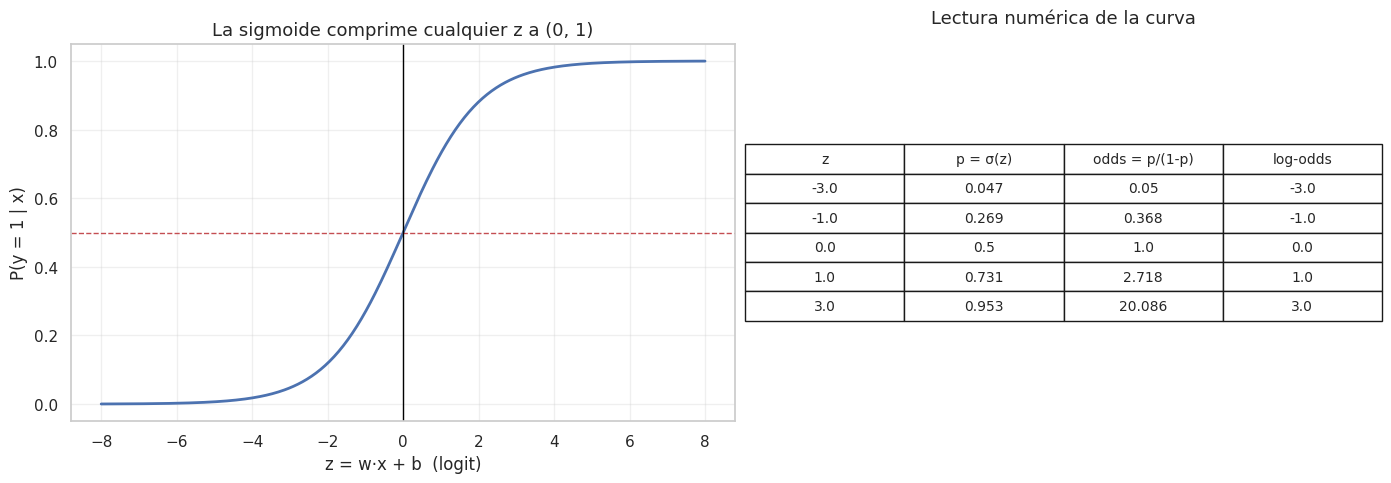

Subir z en +1 multiplica los odds por e ≈ 2.718, no suma 1.0 a la probabilidad.


In [ ]:
# PASO 2 — La sigmoide en numeros
# Completar:
# - una funcion sigmoide(z) con np.clip para no desbordar el exp
# - un grafico de p vs z entre -8 y 8, con lineas en p=0.5 y z=0
# - una tabla con z en [-3, -1, 0, 1, 3], columnas p, odds y log-odds
# - una frase impresa: subir z en +1 multiplica los odds por e, no suma 1 a p

def sigmoide(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))


# Datos de la curva
z = np.linspace(-8, 8, 400)
p = sigmoide(z)

# Datos numéricos
ejemplos_z = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
p_ejemplos = sigmoide(ejemplos_z)

tabla_sig = pd.DataFrame({
    "z": ejemplos_z,
    "p = σ(z)": p_ejemplos,
    "odds = p/(1-p)": p_ejemplos / (1 - p_ejemplos),
    "log-odds": np.log(p_ejemplos / (1 - p_ejemplos)),
}).round(3)


# Crear figura
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [1.2, 1]}
)

# -------------------------
# GRÁFICO IZQUIERDO
# -------------------------
axes[0].plot(z, p, color="#4C72B0", lw=2)

axes[0].axhline(
    0.5,
    color="#C44E52",
    ls="--",
    lw=1,
    label="p = 0.5"
)

axes[0].axvline(
    0,
    color="black",
    lw=1
)

axes[0].set_xlabel("z = w·x + b  (logit)")
axes[0].set_ylabel("P(y = 1 | x)")
axes[0].set_title(
    "La sigmoide comprime cualquier z a (0, 1)"
)

axes[0].set_xlim(-8.8, 8.8)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(alpha=0.3)


# -------------------------
# TABLA DERECHA
# -------------------------
axes[1].axis("off")

axes[1].set_title(
    "Lectura numérica de la curva",
    pad=15
)

tabla = axes[1].table(
    cellText=tabla_sig.values,
    colLabels=tabla_sig.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.15, 1.8)


# Ajustar espacios
plt.tight_layout()
plt.show()


print(
    "Subir z en +1 multiplica los odds por e ≈ 2.718, "
    "no suma 1.0 a la probabilidad."
)

#### Por qué se entrena con log-loss y no con MSE

Si usáramos error cuadrático sobre $p$, el problema deja de ser convexo y el gradiente se **aplana** cuando el modelo está muy equivocado (malas noticias: justamente ahí necesitamos empujar fuerte).

La pérdida de la logística (binary cross-entropy / log-loss) para un ejemplo es:

$$
\mathcal{L} = -\big[ y \log p + (1-y)\log(1-p) \big]
$$

* Si $y=1$ y $p \to 0$, $\mathcal{L} \to +\infty$ (castigo enorme por estar seguro y fallar).
* Si $y=1$ y $p \to 1$, $\mathcal{L} \to 0$.

sklearn minimiza eso (más regularización) con el `solver` que elijas. `predict_proba` es el $p$ de esa pérdida, no un score arbitrario de un árbol.

> **Para discutir.**  
> 1. Si $p=0.51$ y $p=0.99$ dan la misma clase con $\tau=0.50$, ¿el negocio los trata igual?  
> 2. ¿Por qué un coeficiente grande en una dummy one-hot no se lee igual que un coeficiente sobre `tenure` sin escalar?

### Bloque 1 — Carga y primera mirada

Cada fila es **un cliente**. `Churn = Yes` significa que se fue en el último mes.

| Columna | Qué es | Rol |
|---|---|---|
| `customerID` | identificador | **no** es feature |
| `gender`, `SeniorCitizen`, `Partner`, `Dependents` | demografía | features |
| `tenure` | meses como cliente | feature numérica clave |
| `PhoneService`, `MultipleLines`, `InternetService`, … | productos | features categóricas |
| `Contract` | mes a mes / 1 año / 2 años | feature (muy predictiva en churn) |
| `PaperlessBilling`, `PaymentMethod` | facturación | features |
| `MonthlyCharges` | cargo mensual actual | feature |
| `TotalCharges` | facturado acumulado | feature **delicada** (ver limpieza) |
| `Churn` | se fue / no se fue | **target** |

In [ ]:
# PASO 3 — Cargar y mirar
# Completar:
# - raw = pd.read_csv(DATA_PATH)
# - shape y head
# - tabla con dtype, faltantes, % faltantes, unicos y un ejemplo por columna
# - value_counts de Churn con porcentaje
raw = pd.read_csv(DATA_PATH)
print("Filas, Columnas:", raw.shape)
print("Revision basica",raw.info())
print("Metricas:\n",raw.describe())
print("Valores faltantes:\n",raw.isna().sum())

Filas, Columnas: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

In [ ]:
raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Bloque 2 — Limpieza

Problemas típicos de esta base (documentados, reproducibles):

1. **`TotalCharges` viene como texto.** Hay ~11 filas con string vacío: son clientes con `tenure = 0` (todavía no les facturaron). Convertimos a número y ponemos `0`.
2. **`SeniorCitizen` es 0/1 numérico** pero es una categoría. Lo pasamos a `Yes`/`No` para que el one-hot lo trate igual que `Partner`.
3. **`customerID` no aporta señal.** Fuera del modelo.
4. **Servicios con valor `No internet service` / `No phone service`.** No son un tercer producto misterioso: son consecuencia de no tener internet o teléfono. Los dejamos (el modelo puede usarlos) pero no los inventamos como numéricos.
5. **No hay precios corruptos tipo 32-bit** como en Sydney. El riesgo acá es **leakage conceptual** y **multicolinealidad**, no outliers de baños = 99.

Regla: la función de limpieza no mira el test por separado porque todavía no hay split. Solo corrige tipos y basura de registro.

In [ ]:
# PASO 4 — Limpieza
# Escribir limpiar_telco(df) que:
# - pase TotalCharges a numero (los vacios de tenure 0 quedan en 0)
# - mapee SeniorCitizen 0/1 a "No"/"Yes"
# - cree churn = 1 si Churn == "Yes"
# - imprima filas, cuantos TotalCharges no eran numericos y faltantes residuales
# Aplicarla a raw y mostrar head + proporcion de churn.

def limpiar_telco(df: pd.DataFrame) -> pd.DataFrame:
  # Limpieza reporducible
  out = df.copy()
  n0 = len(out)

  out['TotalCharges'] = pd.to_numeric(out["TotalCharges"], errors="coerce")
  n_total_na = int(out["TotalCharges"].isna().sum())
  #Clientes nuevos: ternure 0 -> todavia no hay acumulado
  out.loc[out["TotalCharges"].isna() & (out["tenure"] == 0), "TotalCharges"] = 0.0

  out["SeniorCitizen"] = out["SeniorCitizen"].map({0: "NO", 1: "YES"})
  out["Churn"] = (out["Churn"] == "Yes").astype(int)

  n1 = len(out)

  print(f"Filas originales: {n0:,}")
  print(f"Filas despues: {n1:,}")
  print(f"TotalCharges no numericos: {n_total_na:,}")
  print(f"TotalCharges imputados a 0: {int((out["TotalCharges"] == 0).sum())} incluye ternure en 0")
  print(f"Faltantes residuales numericos: {out[['tenure', 'MonthlyCharges', 'TotalCharges']].isna().sum().sum()}")
  return out.reset_index(drop = True)

In [ ]:
df = limpiar_telco(raw)
df.head()

Filas originales: 7,043
Filas despues: 7,043
TotalCharges no numericos: 11
TotalCharges imputados a 0: 11 incluye ternure en 0
Faltantes residuales numericos: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,NO,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,NO,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,NO,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,NO,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,NO,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
print("Churn numerico (1 = se fue) \n")
print(df['Churn'].value_counts().to_frame('n').assign(pct=lambda d: (d['n'] / d['n'].sum()).round(2)))

Churn numerico (1 = se fue) 

          n   pct
Churn            
0      5174  0.73
1      1869  0.27


### Bloque 3 — Exploración (todavía sin modelo)

Tres preguntas antes de entrenar:

1. **¿Qué estoy prediciendo?** Si el cliente se va el próximo período (`churn = 1`).
2. **¿Está balanceado?** No: ~26.5% positivos. Accuracy va a quedar inflado.
3. **¿Qué se conocía al decidir una oferta de retención?** Todo menos el propio `Churn`. `customerID` tampoco.

Hipótesis de negocio que la EDA debería o no confirmar:

* Contrato mes a mes $\Rightarrow$ más churn.
* `tenure` alto $\Rightarrow$ menos churn (ya “sobrevivió”).
* Fibra óptica $\Rightarrow$ a menudo más churn (precio / expectativa).
* Cheque electrónico $\Rightarrow$ más churn que débito automático.

Medidas numericas por clase
       tenure  MonthlyCharges  TotalCharges
Churn                                      
0       37.57           61.27       2549.91
1       17.98           74.44       1531.80


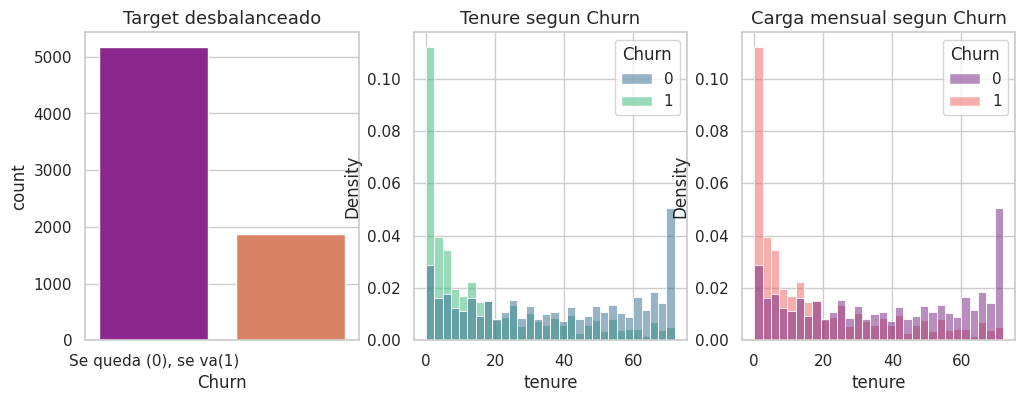

In [ ]:
# PASO 5 — Tres graficos, todavia sin modelo
# Completar en una figura de 1x3:
# - countplot de churn
# - histograma de tenure por churn (densidad, common_norm=False)
# - histograma de MonthlyCharges por churn
# Despues: media de tenure, MonthlyCharges y TotalCharges por clase.
fig, axes = plt.subplots(1, 3, figsize=(12,4))
sns.countplot(data = df, x="Churn", palette='plasma', ax = axes[0])
axes[0].set_xticklabels(["Se queda (0), se va(1)"])
axes[0].set_title("Target desbalanceado")

sns.histplot(data = df, x="tenure", hue="Churn", bins=30, stat="density", common_norm=False, palette='viridis', ax = axes[1])
axes[1].set_title("Tenure segun Churn")

sns.histplot(data = df, x="tenure", hue="Churn", bins=30, stat="density", common_norm=False, palette='magma', ax = axes[2])
axes[2].set_title("Carga mensual segun Churn")

print("Medidas numericas por clase")

print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2))


In [ ]:
# PASO 6 — Tasa de churn por categoria
# Para Contract, InternetService, PaymentMethod, Partner, Dependents y PaperlessBilling:
# - tabla con n y tasa de churn por nivel
# - un barh de la tasa por variable (grilla 2x3)
cast_clave = ['Contrat', 'InternetService', 'PaymentMethod', 'Partener', 'Dependents', 'PaperlessBilling']
filas = []
for col in cast_clave:
  tab = df.groupby(col['Churn'].agg(n='size', tasa_churn='mean').reset_index())
  tab.insert(0,"variable", col)
  tab = tab.rename(columns={col:"nivel"})
  filas.append(tab)

churn_x_cat = pd.concat(filas, ignore_index=True)
print(churn_x_cat.round(3))

# graficamos

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), cast_clave):
  tasas = df.groupby(col['churn'].mean().sort_values())
  tasas.plot(kind='brat', ax = ax, color='red')
  ax.set_xlabel("P(churn)")
  ax.set_xlim(0, 0.5)
  plt.tight_layout()
  plt.show()




TypeError: string indices must be integers, not 'str'

In [ ]:
# PASO 7 — Numericas y correlacion
# Completar:
# - describe de tenure, MonthlyCharges, TotalCharges, churn
# - heatmap de correlacion
# - imprimir corr(tenure, TotalCharges) y una frase sobre multicolinealidad

num_eda = ['tenure', 'MonthlyCharges', 'Total']

> **Para discutir.**  
> 1. ¿Por qué `TotalCharges` puede correlacionar **negativo** con churn aunque un cliente “gastó más”? Pista: quien acumuló mucho facturado **lleva muchos meses**.  
> 2. Si un contrato de 2 años tiene poca tasa de churn, ¿es lealtad o es que **no puede irse** hasta que vence?  
> 3. ¿Incluirías `gender` por defecto? ¿Qué mirarías antes de dejarlo o sacarlo?

### Bloque 4 — Target, split y features

**Target:** `churn` (1 = se fue).

**Features válidas** (conocidas en el CRM antes de que se vaya, o al menos antes de etiquetar):

* numéricas: `tenure`, `MonthlyCharges`  
  (`TotalCharges` la dejamos **fuera del modelo principal** para no duplicar antigüedad; más abajo hay un experimento que la reincorpora).
* categóricas: demografía, productos, contrato, pago.

**Excluidas a propósito:**

| Columna | Por qué |
|---|---|
| `customerID` | ID, sobreajusta ruido |
| `Churn` / `churn` | es la respuesta |
| `TotalCharges` (en el modelo base) | casi `tenure × precio`; infla coeficientes inestables |

**Split estratificado.** Sin `stratify=y` el test puede quedar con 22% o 30% de churn por azar y las métricas bailan.

In [ ]:
# PASO 8 — Split estratificado
# Completar:
# - NUM_COLS = ["tenure", "MonthlyCharges"]
# - CAT_COLS con el resto de features validas (sin customerID, sin Churn, sin TotalCharges)
# - train_test_split test_size=0.25, random_state=42, stratify=y
# - imprimir tamanos y % de churn en train y en test (tienen que parecerse)


### Bloque 5 — Pipeline, baseline y logística “de fábrica”

| Pieza | Elección | Por qué |
|---|---|---|
| Imputación numérica | mediana | defensa; acá casi no hay NaN |
| Escalado | `StandardScaler` | la logística penaliza en escala de $w$; sin escalar, `MonthlyCharges` (~70) pisa a dummies 0/1 |
| Categóricas | `OneHotEncoder(handle_unknown="ignore")` | niveles nuevos en producción no deben romper |
| Baseline | `DummyClassifier(strategy="most_frequent")` | “nadie se va” |
| Baseline 2 | `DummyClassifier(strategy="stratified")` | azar con la tasa real |
| Modelo | `LogisticRegression` con defaults conscientes | `max_iter` alto, `class_weight="balanced"` en el modelo de trabajo |
| Protocolo | fit en train, métricas en test **una vez** para el modelo elegido | CV se hace **dentro** del train |

In [ ]:
# PASO 9 — Pipeline, dos baselines y la logistica
# Completar:
# - armar_preproceso: mediana + StandardScaler en numericas; moda + OneHotEncoder en categoricas
# - armar_clf: Pipeline(prep, modelo)
# - metricas_clf: accuracy, balanced_acc, precision, recall, f1, roc_auc, pr_auc, log_loss
# - entrenar: Dummy most_frequent, Dummy stratified, LogisticRegression(max_iter=2000, class_weight="balanced")
# - tabla comparativa sobre el TEST
# Guardar los pipes en un dict. El de la logistica se usa en los pasos siguientes.


### Bloque 6 — Enciclopedia de parámetros de `LogisticRegression`

Firma típica (sklearn ≥ 1.5):

```python
LogisticRegression(
    penalty="l2",        # "l1" | "l2" | "elasticnet" | None
    C=1.0,               # 1 / fuerza de regularización
    class_weight=None,   # None | "balanced" | {0: w0, 1: w1}
    solver="lbfgs",      # lbfgs, liblinear, newton-cg, newton-cholesky, sag, saga
    max_iter=100,
    fit_intercept=True,
    l1_ratio=None,       # solo con elasticnet (0 = L2, 1 = L1)
    tol=1e-4,
    random_state=None,   # solvers estocásticos / liblinear
)
```

#### 6.1 `penalty` — qué le prohibís al vector $w$

| Valor | Qué hace | Efecto práctico |
|---|---|---|
| `"l2"` (default) | penaliza $\sum w_j^2$ | achica coeficientes, **no** los pone en cero. Estable. |
| `"l1"` | penaliza $\sum |w_j|$ | **esparce**: muchos $w_j = 0$. Selección de variables. |
| `"elasticnet"` | mezcla L1 y L2 | útil si hay grupos de dummies correlacionadas. Requiere `solver="saga"`. |
| `None` | sin penalización | solo si $n \gg p$ y está bien condicionado. Fácil que se descontrole. |

L2 es el default razonable. L1 brilla cuando hay **muchas** columnas one-hot y querés un modelo más chico.

#### 6.2 `C` — el dial más importante después del umbral

$$
C = \frac{1}{\lambda}
$$

* **`C` chico** (0.01): regularización **fuerte** → modelo simple, sesgo alto, menos sobreajuste.
* **`C` grande** (100): regularización **débil** → se pega al train, coeficientes grandes.

No es “más C = más accuracy”. Es el trade-off sesgo/varianza. Se elige por **CV en el train**, no mirando el test 20 veces.

#### 6.3 `class_weight` — qué tanto le duele errar cada clase

| Valor | Qué hace |
|---|---|
| `None` | cada fila pesa 1. Con 26% de churn, el modelo se acomoda a predecir “se queda”. |
| `"balanced"` | peso $\propto 1 / \text{frecuencia}$. Equivale a subir el costo de perder un churn. |
| `{0: 1, 1: 3}` | receta explícita: un falso negativo “vale” 3 veces un falso positivo (en el *fit*, no en la métrica). |

`class_weight` **no reemplaza** elegir el umbral. Mueve las probabilidades / el logit. El umbral sigue siendo tuyo.

#### 6.4 `solver` — el algoritmo que minimiza la pérdida

| Solver | Penalties | Notas |
|---|---|---|
| `lbfgs` | L2, None | default moderno, estable en problemas medianos. |
| `liblinear` | L1, L2 | bueno en $p$ grande y $n$ no enorme; binario / OvR. |
| `saga` | L1, L2, elasticnet, None | el más versátil; datos grandes. |
| `sag` | L2, None | datasets grandes, features densas. |
| `newton-cg` / `newton-cholesky` | L2, None | a veces más rápido con $p$ chico. |

Si pedís `penalty="l1"` con `solver="lbfgs"` sklearn **revienta**. Hay combinaciones incompatibles: no es capricho, es matemática del optimizador.

#### 6.5 `max_iter` y `tol`

* `max_iter`: tope de iteraciones. Warning de convergencia $\Rightarrow$ subilo (2000 es un default de clase sano) o escalá / bajá `C`.
* `tol`: cuándo declara “ya está”. Más chico = más preciso y más lento.

Un modelo que **no convergió** no es “un poco peor”: los coeficientes pueden ser basura.

#### 6.6 `fit_intercept`

Dejarlo en `True` salvo que hayas centrado a mano y sepas por qué. El intercepto es el logit cuando todas las features (escaladas) valen 0: un cliente “promedio” del train.

#### 6.7 `l1_ratio`

Solo con `penalty="elasticnet"`. `0` = L2 pura, `1` = L1 pura, `0.5` = mitad y mitad.

#### 6.8 Lo que **no** es un parámetro del estimador

* El **umbral** 0.50: vive en `predict`, no en `fit`.
* El **test size**: es del split.
* La **métrica de CV**: es de `GridSearchCV` / `cross_val_score`.

In [ ]:
# PASO 10 — Que combinaciones penalty x solver existen
# Probar estas parejas y anotar si fit() funciona o que excepcion tira:
# (l2, lbfgs), (l2, liblinear), (l1, liblinear), (l1, saga), (elasticnet, saga), (l1, lbfgs)
# elasticnet necesita l1_ratio=0.5
# La ultima tiene que fallar. No la "arregles".


### Bloque 7 — Enciclopedia de métricas (con este negocio en la cabeza)

Definimos el **positivo** = cliente que **se va** (`churn = 1`). En retención, casi siempre querés **encontrar** a los que se van.

De la matriz de confusión salen cuatro conteos:

|  | Predicho 0 (se queda) | Predicho 1 (se va) |
|---|---|---|
| Real 0 | **TN** verdadero negativo | **FP** falso positivo (oferta al que se quedaba) |
| Real 1 | **FN** falso negativo (se fue y no lo viste) | **TP** verdadero positivo |

#### 7.1 Accuracy — $\frac{TP+TN}{TP+TN+FP+FN}$

Proporción de aciertos. Con 73.5% de clase 0, un loro que dice “se queda” ya tiene 0.735. **No es la métrica de este problema.** Úsala solo como referencia o cuando las clases y los costos son simétricos (Iris sí; churn no).

#### 7.2 Precision (de churn) — $\frac{TP}{TP+FP}$

De los que marqué “se va”, ¿cuántos se fueron de verdad?  
Alta precision = pocas ofertas tiradas a la basura. Baja = llamás a mucha gente que no se iba.

#### 7.3 Recall / sensibilidad / TPR — $\frac{TP}{TP+FN}$

De los que **sí se fueron**, ¿a cuántos detecté?  
Alto recall = pocos clientes perdidos sin intento de retención. Es la métrica que un gerente de churn suele pedir primero.

#### 7.4 Specificity / TNR — $\frac{TN}{TN+FP}$

De los que se quedan, ¿a cuántos no molesté? El complemento de la tasa de falsas alarmas.

#### 7.5 F1 — media armónica de precision y recall

$$
F_1 = 2 \cdot \frac{\text{prec} \cdot \text{rec}}{\text{prec} + \text{rec}}
$$

Castiga el desequilibrio entre las dos. No mira TN: un modelo puede tener F1 lindo y ser un desastre si te importan los negativos.

#### 7.6 Fβ — cuando el recall vale más (o menos)

$$
F_\beta = (1+\beta^2)\frac{\text{prec} \cdot \text{rec}}{\beta^2 \cdot \text{prec} + \text{rec}}
$$

* $\beta = 2$ ($F_2$): el recall pesa más. Típico si perder un cliente es caro.
* $\beta = 0.5$: la precision pesa más. Típico si la oferta es carísima.

#### 7.7 Balanced accuracy — $\frac{\text{sensibilidad} + \text{especificidad}}{2}$

Accuracy que le da el mismo peso a las dos clases. Útil para comparar contra la mayoritaria.

#### 7.8 ROC-AUC

Probabilidad de que un positivo al azar tenga **mayor** $p$ que un negativo al azar. Mide **ordenamiento**, no un umbral.  
Insensible (demasiado) al desbalance: puede verse “linda” (~0.84) aunque el PR sea mediocre. Siempre mirala **junto** con PR-AUC.

La curva ROC: eje X = FPR $=\frac{FP}{FP+TN}$, eje Y = TPR (recall). El azar es la diagonal.

#### 7.9 PR-AUC / average precision

Área bajo precision-recall. El baseline no es 0.50: es la **prevalencia** $P(y=1)$ (~0.265).  
En desbalance, esta curva es más honesta que ROC.

#### 7.10 Log-loss

$$
-\frac{1}{n}\sum_i \big[ y_i \log p_i + (1-y_i)\log(1-p_i) \big]
$$

Castiga las probabilidades mal calibradas y las predicciones “seguras y falsas”. Más bajo = mejor. No depende del umbral.

#### 7.11 Brier score — $\frac{1}{n}\sum (p_i - y_i)^2$

Error cuadrático de las probabilidades. Más bajo = mejor. Sirve para calibración.

#### 7.12 MCC (Matthews) y Kappa de Cohen

Resúmenes que usan los cuatro cuadrantes. MCC = 0 es azar, 1 es perfecto, −1 es invertir etiquetas. Útiles cuando querés **un** número que no se deje engañar por el desbalance tanto como el accuracy.

#### Cómo elegir en esta telco

| Pregunta de negocio | Métrica |
|---|---|
| ¿El modelo ordena quién se va? | ROC-AUC + PR-AUC |
| ¿Detectamos a los que se van? | recall / $F_2$ |
| ¿Las llamadas de retención son caras? | precision |
| ¿Las $p$ sirven para un ranking de campañas? | log-loss, Brier, calibración |
| ¿Le muestro un número al directorio sin contexto? | **ninguna sola**; mostrá matriz + costos |

In [ ]:
# PASO 11 — Todas las metricas sobre un solo modelo
# Con la logistica balanced y umbral 0.50, sobre el test:
# - TN, FP, FN, TP
# - accuracy, balanced accuracy, precision, recall, especificidad, FPR, F1, F2, ROC-AUC,
#   PR-AUC, log-loss, Brier, MCC, kappa
# - classification_report con nombres "se queda (0)" y "se va (1)"
# Al lado de cada metrica, una columna corta de lectura (que pregunta responde).


### Bloque 8 — Matriz de confusión, ROC y Precision-Recall

Tres dibujos, tres preguntas distintas:

1. **Matriz:** con *este* umbral, ¿cuántos FP y FN?
2. **ROC:** si recorro todos los umbrales, ¿ordeno bien positivos vs negativos?
3. **PR:** lo mismo, pero en el lenguaje del desbalance (precision vs recall).

In [ ]:
# PASO 12 — Tres dibujos
# En una fila:
# - matriz de confusion (se queda / se va)
# - curva ROC con la diagonal de azar
# - curva precision-recall con una linea horizontal en la prevalencia del test


### Bloque 9 — Umbral de decisión (el parámetro que no está en `fit`)

`predict` usa $\tau = 0.50$. En retención casi nunca es el óptimo.

* **Bajar** $\tau$ (0.30): más gente marcada como de riesgo $\rightarrow$ **sube recall, baja precision**.
* **Subir** $\tau$ (0.70): solo los muy claros $\rightarrow$ **sube precision, baja recall**.

Vamos a barrer umbrales y, aparte, a poner **plata** en los errores:

* Costo de un **FN**: perdés al cliente (ejemplo: 400 USD de margen futuro).
* Costo de un **FP**: regalás un descuento a quien se quedaba (ejemplo: 40 USD).

El umbral “óptimo” es el que **minimiza el costo esperado en el train** (o en un fold de validación), no el que maximiza accuracy en el test. Acá lo mostramos en test **solo como demostración pedagógica**; en un trabajo real lo fijarías con CV.

In [ ]:
# PASO 13 — Umbral y costo
# Barrer umbrales de 0.20 a 0.80.
# Para cada uno: marcados, precision, recall, f1, f2, TN/FP/FN/TP
# y costo = 400*FN + 40*FP.
# Graficar recall/precision/F2 vs umbral, y el costo vs umbral.
# Marcar el umbral de menor costo y escribir que esto es una DEMO en test:
# en serio el umbral se elige con validacion.


### Bloque 10 — Regularización: el dial `C` y L1 vs L2

Intuición:

* Dataset con muchas dummies (contrato, método de pago, servicios…) $\rightarrow$ fácil memorizar combinaciones raras del train.
* `C` chico obliga a $w$ chico $\rightarrow$ el modelo no puede “gritar” por una dummy de 20 filas.

Vamos a entrenar **solo en train** varios `C` y mirar métricas de **CV**, no 15 miradas al test. Al final, una fila de test para el `C` elegido.

In [ ]:
# PASO 14 — El dial C, con validacion cruzada (no con el test)
# StratifiedKFold(5, shuffle=True, random_state=42)
# Para C en [0.01, 0.1, 1, 10, 100]: media y desvio de ROC-AUC y de F1 en el TRAIN.
# Grafico de AUC vs C en escala log.
# Si varios C empatan dentro de 1 desvio, quedarse con el C mas chico.
# Guardar ese valor en C_star.


In [ ]:
# PASO 15 — L2 vs L1 vs elastic-net
# Misma C=1, class_weight balanced:
# - L2 con lbfgs
# - L1 con saga
# - elasticnet l1_ratio=0.5 con saga
# Comparar metricas y, ademas, cuantos coeficientes quedan distintos de 0 y las normas L1 y L2 de w.


### Bloque 11 — `class_weight`, escalado y solvers (experimentos)

Tres errores de laboratorio muy comunes:

1. Olvidar el desbalance y conformarte con accuracy.
2. No escalar y después “interpretar” que `MonthlyCharges` es más importante que `Contract`.
3. Cambiar `solver` como si fuera un hiperparámetro de predicción (casi nunca mueve el AUC; mueve tiempo y qué `penalty` podés usar).

In [ ]:
# PASO 16 — class_weight
# Comparar en el test, umbral 0.50 fijo:
# None, "balanced", {0: 1, 1: 2}, {0: 1, 1: 4}
# Mirar sobre todo recall, precision y ROC-AUC.
# Escribir la lectura: el peso mueve el punto de operacion; el AUC casi no.


In [ ]:
# PASO 17 — Con StandardScaler y sin el
# Mismos hiperparametros.
# Comparar metricas Y el coeficiente crudo de tenure y de MonthlyCharges.
# La frase que tiene que quedar: sin escalar no se comparan |w|.


In [ ]:
# PASO 18 — Solvers
# lbfgs, liblinear, newton-cg, saga. Todos con penalty l2.
# Medir segundos de fit, n_iter y las metricas.
# Elegir por compatibilidad y tiempo, no por "el AUC mas lindo en el cuarto decimal".


#### 11.4 `GridSearchCV` — buscar `C` y `class_weight` sin mirar el test

Un loop a mano está bien para entender. En un trabajo, `GridSearchCV` hace lo mismo: **CV dentro del train**, una métrica de selección, y recién después evaluás el `best_estimator_` en test.

Acá la métrica de selección es `average_precision` (PR-AUC): en desbalance suele ser más exigente que ROC-AUC.

In [ ]:
# PASO 19 — GridSearchCV dentro del train
# Grilla: modelo__C en [0.05, 0.2, 1, 5] y modelo__class_weight en [None, "balanced"].
# scoring = "average_precision", el mismo cv de antes, refit=True.
# Mostrar la tabla de resultados (train y validacion) y las metricas del best_estimator_ en el test, una sola vez.


#### 11.5 Curva de aprendizaje — ¿faltan datos o falta modelo?

La learning curve entrena con 10%, 25%, …, 100% del **train** y mide CV. Lectura:

* Train alto y validación baja que **no se juntan** al agregar filas → modelo demasiado flexible o features ruidosas (varianza).
* Train y validación juntas pero **bajas** → el modelo es pobre o faltan features (sesgo). La logística a veces vive acá: no captura interacciones (`fibra × mes a mes`) salvo que las armes a mano.
* Las dos suben y se acercan → más datos ayudarían.

In [ ]:
# PASO 20 — Learning curve
# learning_curve con ROC-AUC, 6 tamanos de train entre 15% y 100%, el mismo cv.
# Tabla y grafico: AUC de train vs AUC de validacion, con banda de desvio.
# Decidir en una frase: sesgo, varianza, o ya estan juntos.


### Bloque 12 — Validación cruzada (el test no se toca)

`StratifiedKFold` mantiene la tasa de churn en cada pliegue. Reportamos media ± desvío: un AUC 0.84 ± 0.01 es otra historia que 0.84 ± 0.08.

Scoring posible (strings de sklearn): `roc_auc`, `average_precision`, `f1`, `recall`, `neg_log_loss`, `balanced_accuracy`.

> Elegir hiperparámetros con 8 métricas distintas en el test es otra forma de overfit. Elegí **una** métrica de selección (acá: `roc_auc` o `average_precision`) y las demás son diagnóstico.

In [ ]:
# PASO 21 — Varias metricas de CV, una sola seleccion
# Con el pipeline de C_star y class_weight balanced, cross_val_score en el TRAIN para:
# roc_auc, average_precision, f1, recall, balanced_accuracy, neg_log_loss.
# Media, desvio y los 5 pliegues.
# Recordar: neg_log_loss esta negado porque sklearn maximiza.


### Bloque 13 — Coeficientes y odds ratios

Con features **escaladas** (numéricas en z-score, dummies 0/1):

* Signo **+**: empuja el logit hacia churn.
* Signo **−**: empuja hacia quedarse.
* Magnitud: en numéricas, “+1 desvío estándar”. En dummies, “ese nivel vs el resto de columnas one-hot” (depende de si el encoder dropea una categoría; acá **no** dropeamos, así que hay dependencia lineal entre dummies de la misma variable: interpretá **diferencias** entre niveles, no un $w$ aislado como verdad absoluta).

**Odds ratio:** $\mathrm{OR}_j = e^{w_j}$.

* OR = 1.40 $\Rightarrow$ +40% en los *odds* de churn (no es +40 puntos porcentuales de probabilidad).
* OR = 0.50 $\Rightarrow$ los odds se reducen a la mitad.

No es causalidad: `Contract_Two year` tiene OR bajo porque quien firma 2 años **no se puede ir ahora**, no necesariamente porque el contrato “cause” lealtad eterna.

In [ ]:
# PASO 22 — Coeficientes y odds ratios
# Entrenar el pipeline final con C_star.
# Tabla: feature, coef, odds_ratio=exp(coef), ordenada por |coef|.
# Imprimir el intercepto y sigmoide(intercepto).
# Barh de los 20 mas grandes: rojo si empuja a churn, azul si empuja a quedarse.


#### 13.1 La trampa de las dummies (`drop="first"`)

Si one-hoteás `Contract` con 3 niveles **sin** dropear, las tres columnas suman 1. El modelo no puede identificar un $w$ único para ese grupo (dependencia lineal con el intercepto). sklearn igual estima algo gracias a la regularización L2, pero **no interpretes un $w$ de `Month-to-month` como efecto causal neto**.

`drop="first"` deja un nivel de referencia: los coeficientes se leen *respecto a esa categoría*. El AUC casi no cambia; la **historia** de los coeficientes sí.

In [ ]:
# PASO 23 — drop="first"
# Entrenar dos pipelines iguales salvo el OneHotEncoder:
# - sin drop
# - drop="first"
# Mostrar solo los coeficientes de Contract y el AUC de cada uno.
# Escribir cual nivel quedo como referencia en la segunda variante.


### Bloque 14 — ¿Las probabilidades están calibradas?

Un modelo **calibrado** cumple: de 100 clientes con $p \approx 0.30$, unos 30 se van.

La logística **suele** salir bastante calibrada (es un modelo de probabilidad). `class_weight="balanced"` **rompe un poco** esa calibración: infla $p$ de la clase rara. Si vas a usar $p$ como “30% de chance” en un reporte ejecutivo, o bien:

* entrenás **sin** `class_weight` y movés el umbral, o
* calibrás después (`CalibratedClassifierCV`) sobre folds del train.

La curva de calibración: eje X = $p$ media del bin, eje Y = frecuencia real de churn. La diagonal es perfecta.

In [ ]:
# PASO 24 — Calibracion
# Curva de calibracion del pipeline final (balanced suele sobreestimar p).
# CalibratedClassifierCV con method="isotonic" y cv=3, ajustado SOLO con train.
# Comparar Brier y AUC antes y despues.
# El AUC no tiene por que mejorar.


### Bloque 15 — Predicciones de ejemplo (varios perfiles)

Armamos clientes hipotéticos con las **mismas columnas** que el train. El pipeline imputa / escala / one-hot igual que en el fit.

Perfiles a propósito:

1. Mes a mes, fibra, poco tenure, cheque electrónico → riesgo alto.
2. Contrato 2 años, mucho tenure, débito automático → riesgo bajo.
3. Igual que (1) pero contrato a 2 años: ¿cuánto baja $p$?
4. Senior, sin partner ni dependientes, paperless, fibra.
5. Sin internet (solo teléfono), contrato anual.

In [ ]:
# PASO 25 — Seis perfiles
# Armar un DataFrame con las mismas columnas que FEATURES:
# 1. mes a mes, fibra, tenure 12, cheque electronico
# 2. igual pero tenure 3 y MonthlyCharges 85
# 3. dos anos, tenure 60, debito automatico
# 4. igual que 2 pero contrato a dos anos
# 5. senior, streaming, cargo alto, mes a mes
# 6. sin internet (acordate de los niveles "No internet service"), un ano, cargo bajo
# Predecir P(churn) y la clase a 0.50 y a 0.40.
# Imprimir cuanto baja p entre el perfil 2 y el 4.


### Bloque 16 — Errores típicos (mini experimentos)

Cuatro trampas que aparecen en examenes y en la industria.

In [ ]:
# PASO 26 — Cuatro trampas
# 1. Accuracy del dummy mayoritario contra la logistica.
# 2. Meter una columna id inventada (0..n) y comparar el AUC. Despues sacarla.
# 3. Reentrenar sumando TotalCharges. Mostrar como se mueven los coeficientes de
#    tenure, MonthlyCharges y TotalCharges. El AUC casi no tiene que subir.
# 4. Buscar el umbral que maximiza accuracy y escribir por que no se usa.
